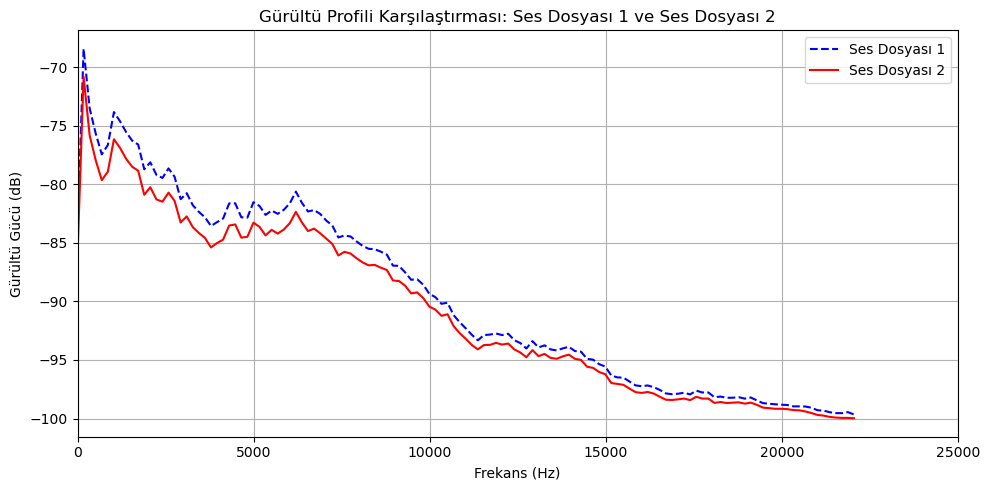

In [38]:
# Gerekli kütüphanelerin içe aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
from scipy import signal

# İşlenecek ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# İşlenecek ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Her iki ses dosyasını da yükle
wave_1, sr_1 = librosa.load(file_1, sr=None)
wave_2, sr_2 = librosa.load(file_2, sr=None)

# Gürültü profilini karşılaştırmak için fonksiyon tanımla
def plot_noise_profile(signal_1, signal_2, sr, label_1, label_2):

# Log hesaplamasında hata olmaması için küçük sabit
	epsilon = 1e-10

# İlk ses için spektrogram ve ortalama güç hesabı
	freqs_1, _, Sxx_1 = signal.spectrogram(signal_1, sr)
	power_1 = np.mean(10 * np.log10(Sxx_1 + epsilon), axis=1)

# İkinci ses için spektrogram ve ortalama güç hesabı
	freqs_2, _, Sxx_2 = signal.spectrogram(signal_2, sr)
	power_2 = np.mean(10 * np.log10(Sxx_2 + epsilon), axis=1)

# Grafik penceresini oluştur ve verileri çiz
	plt.figure(figsize=(10, 5))
	plt.plot(freqs_1, power_1, label=label_1, linestyle="--", color="blue")
	plt.plot(freqs_2, power_2, label=label_2, linestyle="-", color="red")

# Görsel ayarlamalar
	plt.title(f"Gürültü Profili Karşılaştırması: {label_1} ve {label_2}")
	plt.xlabel("Frekans (Hz)")
	plt.ylabel("Gürültü Gücü (dB)")
	plt.xlim(0, 25000)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

# Tanımlanan fonksiyonu çağırarak analiz başlat
plot_noise_profile(wave_1, wave_2, sr_1, label_1, label_2)